# Consideraciones previas para preparar escenario local

In [ ]:
# Volver a la raíz de Colab para empezar de cero
%cd /content/

# Borrar la carpeta si existe para evitar duplicados
!rm -rf reto4_proyecto_ia

# Clonar de nuevo (limpio)
!git clone https://github.com/egilb-uoc/reto4_proyecto_ia.git

# Entrar en la carpeta correcta
%cd reto4_proyecto_ia

# Verificar dónde estamos y qué vemos
import os
print("Tu ruta actual es:", os.getcwd())
print("Archivos y carpetas aquí:", os.listdir())

/content
Cloning into 'reto4_proyecto_ia'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 37 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 1.84 MiB | 6.05 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/reto4_proyecto_ia
Tu ruta actual es: /content/reto4_proyecto_ia
Archivos y carpetas aquí: ['entranamiento_sisfall.ipynb', '.git', 'raw', 'README.md', 'processed', 'output']


In [ ]:
# Instalar la librería de AWS en Colab (sino da error al ejecutar fuera de AWS)
!pip install boto3 -q

# Análisis Exploratorio de Datos (EDA) y Preprocesamiento

## Carga del datatset desde S3 o desde carpeta github processed/

In [ ]:
# Cargar y unir archivos .csv (Modo Híbrido: S3 o Local)

import pandas as pd
import boto3
import os
from botocore.exceptions import NoCredentialsError, ClientError

bucket = 'sisfall-fall-detection'
s3_prefix = 'processed/'
local_path = 'processed/' # Carpeta en tu repositorio clonado

dfs = []
archivos_validos = 0

try:
    # INTENTO Opción 1: Conectar a S3 (Entorno AWS SageMaker AI)
    s3 = boto3.client('s3')
    response = s3.list_objects_v2(Bucket=bucket, Prefix=s3_prefix)

    if 'Contents' in response:
        files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('.csv')]
        print(f"S3: Se encontraron {len(files)} archivos CSV. Iniciando descarga...")

        for file in files:
            obj = s3.get_object(Bucket=bucket, Key=file)
            df = pd.read_csv(obj['Body'])

            # Solo usar datos con label (training)
            if 'label' in df.columns:
                dfs.append(df)
                archivos_validos += 1
        print("✔ Datos cargados exitosamente desde Amazon S3.")
    else:
        raise Exception("El bucket está vacío o no se encontró la ruta.")

except (NoCredentialsError, ClientError, Exception) as e:
    # INTENTO Opción 2: Entorno Local (Colab/GitHub)
    print("⚠ No hay conexión a S3. Buscando archivos en carpeta local...")

    if os.path.exists(local_path):
        files = [f for f in os.listdir(local_path) if f.endswith('.csv')]
        print(f"LOCAL: Se encontraron {len(files)} archivos CSV. Iniciando carga...")

        for file in files:
            ruta_archivo = os.path.join(local_path, file)
            df = pd.read_csv(ruta_archivo)

            # Solo usar datos con label (training)
            if 'label' in df.columns:
                dfs.append(df)
                archivos_validos += 1
        print("Datos cargados exitosamente desde la carpeta local.")
    else:
        print(f"Error crítico: No se encontró la carpeta local '{local_path}'.")

# Consolidar el dataset y mostrar resultados (Tu código original)
if dfs:
    dataset = pd.concat(dfs, ignore_index=True)
    print("\n--- RESUMEN DEL DATASET ---")
    print(f"Archivos unidos: {archivos_validos}")
    print("Shape dataset:", dataset.shape)
    print(dataset['label'].value_counts())
else:
    print("\nError: No se pudo cargar ningún dato con la columna 'label'.")

⚠ No hay conexión a S3. Buscando archivos en carpeta local...
LOCAL: Se encontraron 9 archivos CSV. Iniciando carga...
Datos cargados exitosamente desde la carpeta local.

--- RESUMEN DEL DATASET ---
Archivos unidos: 9
Shape dataset: (62397, 11)
label
0    47398
1    14999
Name: count, dtype: int64


In [ ]:
# Verificamos la existencia del bucket y que lo podemos leer correctamente
'''
import boto3

s3 = boto3.client('s3')

for bucket in s3.list_buckets()['Buckets']:
    print(bucket['Name'])
'''

"\nimport boto3\n\ns3 = boto3.client('s3')\n\nfor bucket in s3.list_buckets()['Buckets']:\n    print(bucket['Name'])\n"

In [ ]:
# Revisión archivos .csv existentes en la carpeta /processed
'''
response = s3.list_objects_v2(
    Bucket='sisfall-fall-detection',
    Prefix='processed/'
)

for obj in response.get('Contents', []):
    print(obj['Key'])
'''

"\nresponse = s3.list_objects_v2(\n    Bucket='sisfall-fall-detection',\n    Prefix='processed/'\n)\n\nfor obj in response.get('Contents', []):\n    print(obj['Key'])\n"

In [ ]:
# Cargar y unir archivos .csv desde S3 (solo con label)
'''
import pandas as pd
import boto3

s3 = boto3.client('s3')

bucket = 'sisfall-fall-detection'

response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix='processed/'
)

files = [obj['Key'] for obj in response['Contents'] if obj['Key'].endswith('.csv')]

dfs = []

for file in files:
    obj = s3.get_object(Bucket=bucket, Key=file)
    df = pd.read_csv(obj['Body'])

    # solo usar datos con label (training)
    if 'label' in df.columns:
        dfs.append(df)

dataset = pd.concat(dfs, ignore_index=True)

print("Shape dataset:", dataset.shape)
print(dataset['label'].value_counts())
'''

'\nimport pandas as pd\nimport boto3\n\ns3 = boto3.client(\'s3\')\n\nbucket = \'sisfall-fall-detection\'\n\nresponse = s3.list_objects_v2(\n    Bucket=bucket,\n    Prefix=\'processed/\'\n)\n\nfiles = [obj[\'Key\'] for obj in response[\'Contents\'] if obj[\'Key\'].endswith(\'.csv\')]\n\ndfs = []\n\nfor file in files:\n    obj = s3.get_object(Bucket=bucket, Key=file)\n    df = pd.read_csv(obj[\'Body\'])\n    \n    # solo usar datos con label (training)\n    if \'label\' in df.columns:\n        dfs.append(df)\n\ndataset = pd.concat(dfs, ignore_index=True)\n\nprint("Shape dataset:", dataset.shape)\nprint(dataset[\'label\'].value_counts())\n'

## Equilibrio del dataset

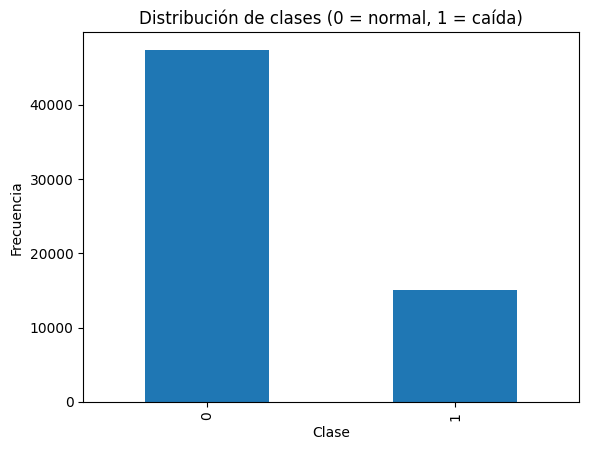

In [ ]:
# Distribución de clases

import matplotlib.pyplot as plt

dataset['label'].value_counts().plot(kind='bar')
plt.title("Distribución de clases (0 = normal, 1 = caída)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

## Análisis de distribución de variables

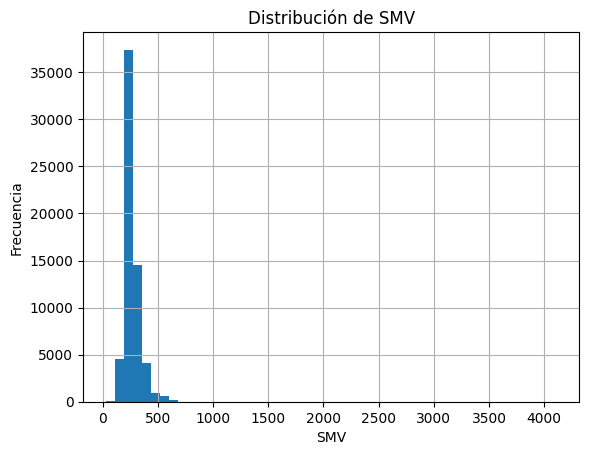

In [ ]:
# Distribución de SMV

dataset['smv'].hist(bins=50)
plt.title("Distribución de SMV")
plt.xlabel("SMV")
plt.ylabel("Frecuencia")
plt.show()

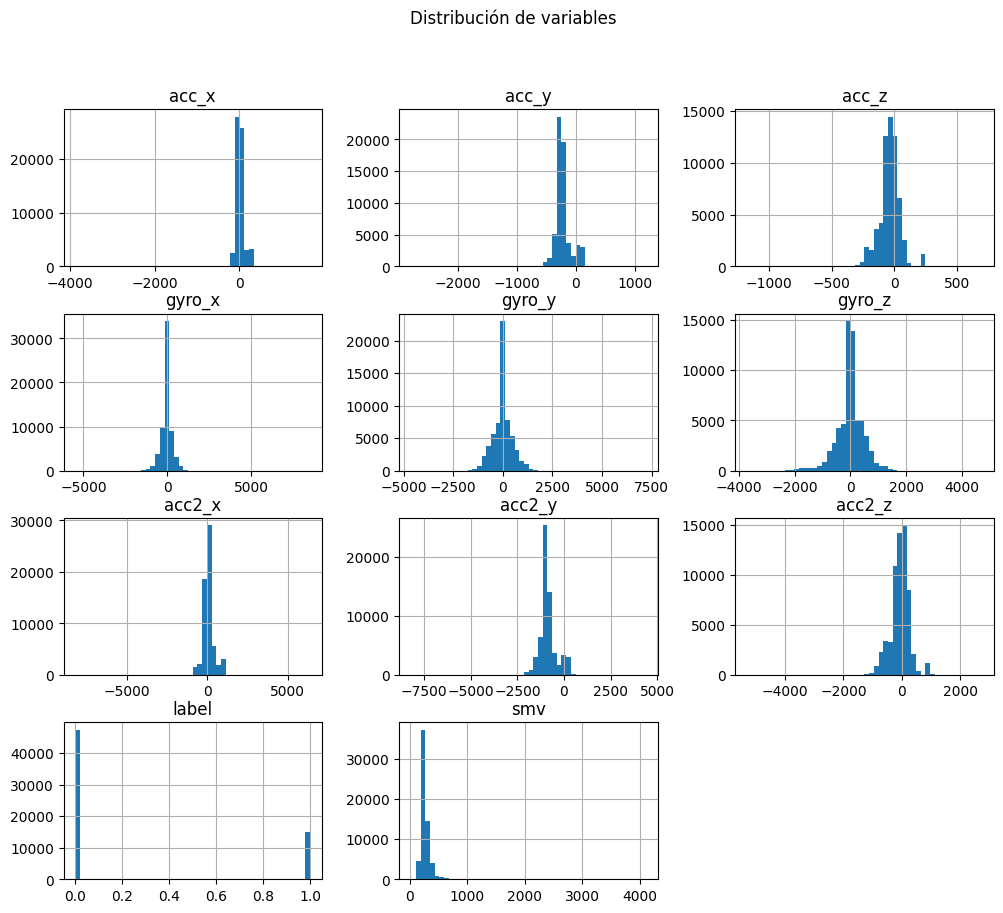

In [ ]:
# Distribución de variables

import matplotlib.pyplot as plt

dataset.hist(figsize=(12,10), bins=50)
plt.suptitle("Distribución de variables")
plt.show()

In [ ]:
# Correlación con la variable target

corr = dataset.corr()

corr_target = corr["label"].sort_values(ascending=False)

print(corr_target)

label     1.000000
acc_y     0.577161
acc2_y    0.576872
acc_x     0.290912
acc2_x    0.277019
gyro_y    0.055801
gyro_x    0.022519
acc_z    -0.008303
gyro_z   -0.021643
smv      -0.049185
acc2_z   -0.121427
Name: label, dtype: float64


In [ ]:
# Validación de estructura del dataset

dataset.head(10)

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc2_x,acc2_y,acc2_z,label,smv
0,14,-249,15,53,25,-1,40,-1022,93,1,249.843951
1,13,-252,16,54,24,-1,43,-1032,84,1,252.841848
2,12,-252,13,57,24,1,40,-1033,85,1,252.620268
3,8,-255,15,62,24,4,34,-1045,83,1,255.566038
4,11,-257,18,69,25,5,42,-1052,84,1,257.864305
5,12,-257,15,76,26,4,35,-1058,87,1,257.716899
6,13,-258,14,82,26,4,30,-1051,85,1,258.706397
7,12,-256,16,88,25,5,34,-1038,81,1,256.780062
8,11,-254,15,93,26,7,32,-1037,76,1,254.680192
9,8,-249,16,92,25,7,31,-1023,77,1,249.641743


# División de los datos

In [ ]:
# Preparar datos (train/test)

from sklearn.model_selection import train_test_split

X = dataset.drop("label", axis=1)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (49917, 10)
Test: (12480, 10)


# Entrenamiento del modelo y realización de las predicciones

## Entrenamiento modelo

In [ ]:
# Entrenar modelo (Random Forest)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

## Evaluar métricas

In [ ]:
# Evaluar modelo (métricas)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9666666666666667
Precision: 0.9996143463170073
Recall: 0.8619886930495511
F1-score: 0.9257142857142857


# (Random Forest) Validación del modelo

## (Random Forest) Pruebas Cuantitativas

In [ ]:
# Validación Cuantitativa

import pandas as pd
import numpy as np

# Obtenemos las predicciones del modelo inicial para localizar los fallos
y_pred_inicial = model.predict(X_test)

# Localizamos los índices exactos de esos 4 ejemplos en el set de test
# Usamos [0] para encontrar el primero que encuentre de cada tipo
idx_tp = np.where((y_test == 1) & (y_pred_inicial == 1))[0][0]
idx_tn = np.where((y_test == 0) & (y_pred_inicial == 0))[0][0]
idx_fn = np.where((y_test == 1) & (y_pred_inicial == 0))[0][0]
idx_fp = np.where((y_test == 0) & (y_pred_inicial == 1))[0][0]

indices = [idx_tp, idx_tn, idx_fn, idx_fp]
titulos = ["CASO 1: ACIERTO CAÍDA", "CASO 2: ACIERTO NORMAL", "CASO 3: FALLO (Falso Negativo)", "CASO 4: FALLO (Falso Positivo)"]

print("=== EXTRACCIÓN DE DATOS REALES ===\n")

for i, idx in enumerate(indices):
    # Pillamos la fila con los 10 sensores reales
    datos_reales = X_test.iloc[[idx]]

    # Predicción del modelo inicial
    pred_ini = model.predict(datos_reales)[0]
    conf_ini = model.predict_proba(datos_reales)[0][pred_ini] * 100

    print(f"{titulos[i]} (Índice: {idx})")
    print(f"DATOS: {datos_reales.to_dict(orient='records')[0]}")
    print(f"Resultado Inicial: {pred_ini} ({conf_ini:.2f}% conf)")
    print("-" * 50)

=== EXTRACCIÓN DE DATOS REALES ===

CASO 1: ACIERTO CAÍDA (Índice: 4)
DATOS: {'acc_x': 16, 'acc_y': -50, 'acc_z': 239, 'gyro_x': -13, 'gyro_y': 69, 'gyro_z': -3, 'acc2_x': 94, 'acc2_y': -194, 'acc2_z': 933, 'smv': 244.69777277286363}
Resultado Inicial: 1 (100.00% conf)
--------------------------------------------------
CASO 2: ACIERTO NORMAL (Índice: 0)
DATOS: {'acc_x': -22, 'acc_y': -253, 'acc_z': -72, 'gyro_x': 17, 'gyro_y': 125, 'gyro_z': 34, 'acc2_x': -68, 'acc2_y': -971, 'acc2_z': -321, 'smv': 263.964012698701}
Resultado Inicial: 0 (74.58% conf)
--------------------------------------------------
CASO 3: FALLO (Falso Negativo) (Índice: 199)
DATOS: {'acc_x': -46, 'acc_y': -255, 'acc_z': -114, 'gyro_x': 155, 'gyro_y': 122, 'gyro_z': -233, 'acc2_x': -273, 'acc2_y': -981, 'acc2_z': -300, 'smv': 283.08479295080474}
Resultado Inicial: 0 (72.49% conf)
--------------------------------------------------
CASO 4: FALLO (Falso Positivo) (Índice: 10898)
DATOS: {'acc_x': -26, 'acc_y': -250, 'acc

## (Random Forest) Matriz de confusion

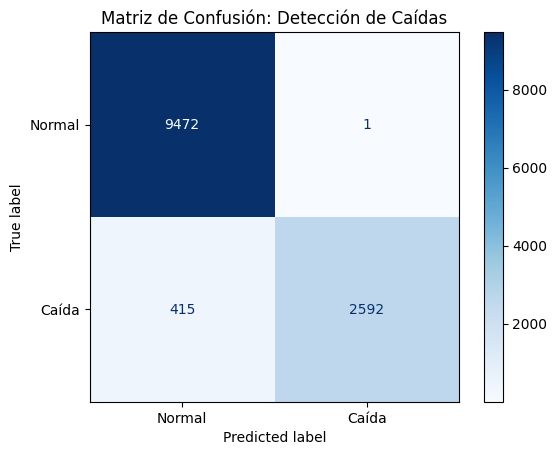

In [ ]:
# Matriz de confusión

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Usamos la función oficial de sklearn que dibuja la matriz automáticamente
# Solo necesita tu 'model', los datos de test y las etiquetas
disp = ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=['Normal', 'Caída'],
    cmap=plt.cm.Blues, # Color azul profesional
    values_format='d'   # Para que salgan números enteros y no decimales
)

# Personalizamos el título
plt.title('Matriz de Confusión: Detección de Caídas')

# Quitamos las líneas de cuadrícula del fondo para que se vea limpia
plt.grid(False)

# Mostramos la imagen
plt.show()

## (Random Forest) Curva de precisión - Recall

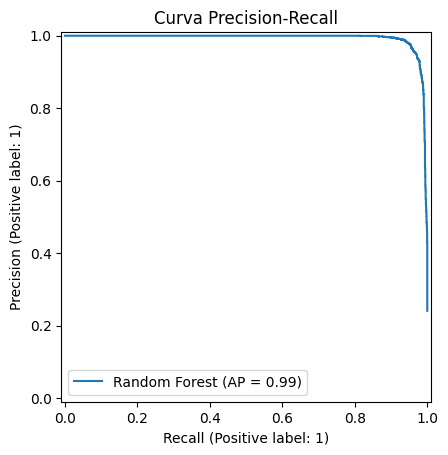

In [ ]:
# Curva de precisión - Recall

from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name="Random Forest")
plt.title('Curva Precision-Recall')
plt.show()

## (Random Forest) Probabilidades de caida

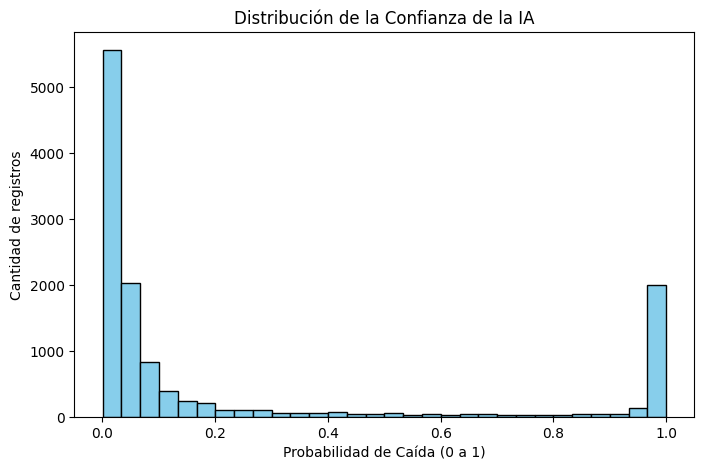

In [ ]:
# Obtenemos las probabilidades de la clase 'Caída'

probs_caida = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_caida, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Confianza de la IA')
plt.xlabel('Probabilidad de Caída (0 a 1)')
plt.ylabel('Cantidad de registros')
plt.show()

## (Random Forest) Intensidad de caidas (SMV)

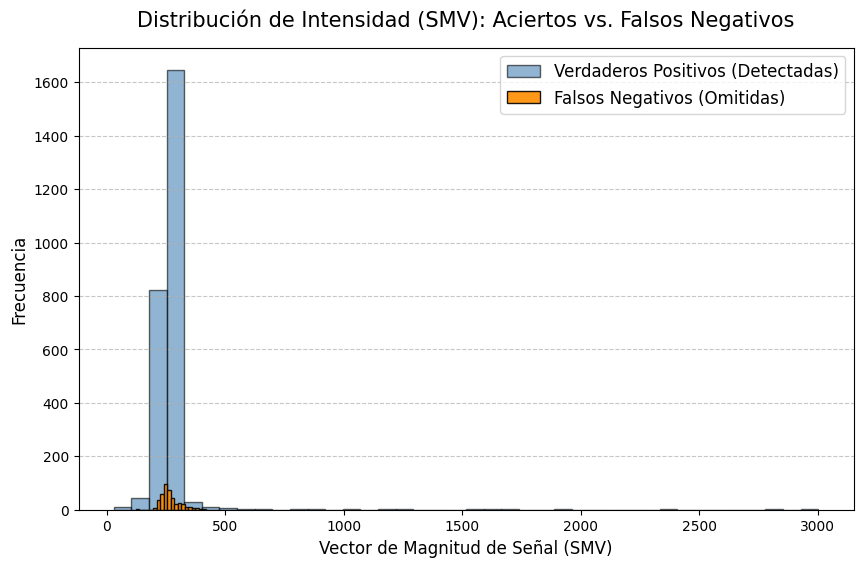

In [ ]:
# Histograma de Intensidad de Caídas (SMV)

import matplotlib.pyplot as plt
import numpy as np

# Filtramos SOLO los casos que en la realidad eran CAÍDAS (y_test == 1)
caidas_reales = X_test[y_test == 1]
predicciones_caidas_reales = model.predict(caidas_reales)

# Separamos el SMV de las que detectamos bien y de las que fallamos
smv_aciertos = caidas_reales[predicciones_caidas_reales == 1]['smv'] # Verdaderos Positivos
smv_fallos = caidas_reales[predicciones_caidas_reales == 0]['smv']   # Falsos Negativos

# Dibujamos el gráfico
plt.figure(figsize=(10, 6))

# Histograma de aciertos (Azul)
plt.hist(smv_aciertos, bins=40, alpha=0.6, label='Verdaderos Positivos (Detectadas)', color='steelblue', edgecolor='black')

# Histograma de fallos (Naranja)
plt.hist(smv_fallos, bins=20, alpha=0.9, label='Falsos Negativos (Omitidas)', color='darkorange', edgecolor='black')

# Personalización formal
plt.title('Distribución de Intensidad (SMV): Aciertos vs. Falsos Negativos', fontsize=15, pad=15)
plt.xlabel('Vector de Magnitud de Señal (SMV)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# (Random Forest) Optimitzación del modelo

## (Random Forest) Buscar mejores hiperparametros con GridSearch (se mantiene comentada para no cargar en tiempo de computación)

In [ ]:
# Buscar mejores hiperparámetros con GridSearch
'''
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Definimos la rejilla (Grid) de parámetros a explorar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced'] # Mantenemos el balanceo para ayudar al Recall
}

# Configuramos GridSearchCV
# scoring='recall' es lo más importante: le decimos que gane el que menos caídas olvide
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=3,       # Validación cruzada en 3 carpetas
    n_jobs=-1,  # Usa todos los procesadores de SageMaker para ir más rápido
    verbose=1   # Para ver el progreso
)

print("=== EJECUTANDO GRID SEARCH (Optimización de Hiperparámetros) ===")
grid_search.fit(X_train, y_train)

# Extraemos los resultados
modelo_grid = grid_search.best_estimator_
print(f"\ Mejores parámetros encontrados: {grid_search.best_params_}")

# Evaluación final
y_pred_grid = modelo_grid.predict(X_test)
print("\nMatriz de Confusión tras Grid Search:")
print(confusion_matrix(y_test, y_pred_grid))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_grid))
'''

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_635/1167544037.py:31: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Mejores parámetros encontrados: {grid_search.best_params_}")


'\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import confusion_matrix, classification_report\n\n# Definimos la rejilla (Grid) de parámetros a explorar\nparam_grid = {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [10, 20, None],\n    \'min_samples_split\': [2, 5, 10],\n    \'class_weight\': [\'balanced\'] # Mantenemos el balanceo para ayudar al Recall\n}\n\n# Configuramos GridSearchCV\n# scoring=\'recall\' es lo más importante: le decimos que gane el que menos caídas olvide\ngrid_search = GridSearchCV(\n    estimator=RandomForestClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'recall\', \n    cv=3,       # Validación cruzada en 3 carpetas\n    n_jobs=-1,  # Usa todos los procesadores de SageMaker para ir más rápido\n    verbose=1   # Para ver el progreso\n)\n\nprint("=== EJECUTANDO GRID SEARCH (Optimización de Hiperparámetros) ===")\ngrid_search.fit(X_train, y_train)\n\

## (Random Forest) Entrenamiento con modelo Random Forest optimizado. Metricas y Matriz de confusión

Entrenando el modelo definitivo...

MÉTRICAS MEJOR MODELO RANDOM FOREST
Accuracy (Exactitud global): 99.44%
Precision (Calidad alarmas): 99.16%
Recall (Caídas detectadas):  98.50%
F1-Score (Equilibrio):       98.83%
Average Precision (AP):      99.95%

 Artefacto guardado exitosamente como 'modelo_sisfall_optimizado.pkl'


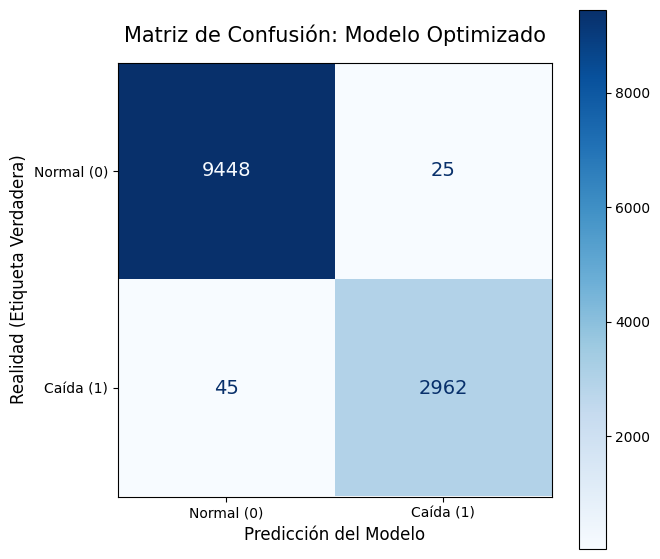

In [ ]:
# Mejor modelo Random Forest con mejores metricas de GridSearch: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}

import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Instanciamos el modelo definitivo con los hiperparámetros mejores proporcionados por Gridsearch
mejor_modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

# Entrenamos el modelo con los datos
print("Entrenando el modelo definitivo...")
mejor_modelo_rf.fit(X_train, y_train)

# Realizamos las predicciones y calculamos probabilidades
y_pred_final = mejor_modelo_rf.predict(X_test)
y_probs_final = mejor_modelo_rf.predict_proba(X_test)[:, 1]

# Cálculo e impresión de métricas para el informe
print("\n" + "="*50)
print("MÉTRICAS MEJOR MODELO RANDOM FOREST")
print("="*50)
print(f"Accuracy (Exactitud global): {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"Precision (Calidad alarmas): {precision_score(y_test, y_pred_final)*100:.2f}%")
print(f"Recall (Caídas detectadas):  {recall_score(y_test, y_pred_final)*100:.2f}%")
print(f"F1-Score (Equilibrio):       {f1_score(y_test, y_pred_final)*100:.2f}%")
print(f"Average Precision (AP):      {average_precision_score(y_test, y_probs_final)*100:.2f}%")
print("="*50)

# Guardamos el artefacto para producción
nombre_archivo = 'modelo_sisfall_optimizado.pkl'
joblib.dump(mejor_modelo_rf, nombre_archivo)
print(f"\n Artefacto guardado exitosamente como '{nombre_archivo}'")

# Dibujamos la Matriz de Confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_final),
    display_labels=['Normal (0)', 'Caída (1)']
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap='Blues', ax=ax, values_format='d', text_kw={'fontsize': 14})

# Personalización de títulos y etiquetas
plt.title('Matriz de Confusión: Modelo Optimizado', fontsize=15, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Realidad (Etiqueta Verdadera)', fontsize=12)
plt.show()

## (Random Forest) Pruebas cuantitativas con modelo optimizado

In [ ]:
# Los mismos 4 casos que probamos en la prueba cualitativa con el modelo inicial, vamos a evaluarlos con el modelo optimizado

import pandas as pd

# Aseguramos el orden de las 10 columnas del modelo
columnas = X_train.columns.tolist()

# Datos registro los mismos registros de test que se han evaluado con el modelo inicial
# Formato: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, smv, acc2_x, acc2_y, acc2_z]
datos_casos = [
    # CASO 1: ACIERTO CAÍDA
    [199.00, 50.00, -155.00, 51.00, 14.00, -4.00, 257.04, -378.00, 32.00, 976.00],
    # CASO 2: ACIERTO NORMAL
    [-17.00, -243.00, -114.00, 111.00, -573.00, -121.00, 269.17, 14.00, -1014.00, -432.00],
    # CASO 3: ANTES FALLO Falso Negativo
    [-15.00, -267.00, -118.00, 121.00, -587.00, -82.00, 292.30, 35.00, -1025.00, -428.00],
    # CASO 4: ANTES FALLO Falso Positivo
    [-26.00, -250.00, -31.00, -134.00, -195.00, 29.00, 253.25, 6.00, -1026.00, -110.00]
]

titulos = [
    "CASO 1: CAÍDA DETECTADA (Anterior Acierto)",
    "CASO 2: ACTIVIDAD NORMAL (Anterior Acierto)",
    "CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo)",
    "CASO 4: ALARMA FALSA (Anterior Falso Positivo)"
]

esperados = [1, 0, 1, 0]

print("=== EVALUACIÓN DEL MODELO OPTIMIZADO ===\n")

for i in range(len(datos_casos)):
    # Creamos el DataFrame con la estructura que el modelo conoce
    X_input = pd.DataFrame([datos_casos[i]], columns=columnas)

    # Predicción con el mejor modelo del GridSearch
    pred = mejor_modelo_rf.predict(X_input)[0]
    prob = mejor_modelo_rf.predict_proba(X_input)[0][pred] * 100

    print(f"--- {titulos[i]} ---")
    print(f"Output Esperado: {esperados[i]} | Output Real: {pred} ({prob:.2f}% confianza)")

    # Verificamos si la optimización ha corregido el error
    if pred == esperados[i]:
        status = "CORRECTO"
        if i >= 2: status += " (¡ERROR CORREGIDO!)"
    else:
        status = "INCORRECTO"

    print(f"Resultado: {status}\n")

=== EVALUACIÓN DEL MODELO OPTIMIZADO ===

--- CASO 1: CAÍDA DETECTADA (Anterior Acierto) ---
Output Esperado: 1 | Output Real: 1 (72.06% confianza)
Resultado: CORRECTO

--- CASO 2: ACTIVIDAD NORMAL (Anterior Acierto) ---
Output Esperado: 0 | Output Real: 1 (72.14% confianza)
Resultado: INCORRECTO

--- CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo) ---
Output Esperado: 1 | Output Real: 1 (74.63% confianza)
Resultado: CORRECTO (¡ERROR CORREGIDO!)

--- CASO 4: ALARMA FALSA (Anterior Falso Positivo) ---
Output Esperado: 0 | Output Real: 1 (75.31% confianza)
Resultado: INCORRECTO



# Probar modelo alternativo XGBoost

## (XGBoost) Entrenamiento del modelo XGBoost y realización de las predicciones

### (XGBoost) Entrenamiento modelo XGBoost

In [ ]:
!pip install xgboost==1.7.6

In [ ]:
# Entrenar modelo (XGBoost)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Calcular peso de clases (para balanceo)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Definir modelo
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Entrenar modelo
xgb_model.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb_model.predict(X_test)

# Resultados
print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred_xgb))


=== MATRIZ DE CONFUSIÓN ===
[[9449   24]
 [  16 2991]]

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9473
           1       0.99      0.99      0.99      3007

    accuracy                           1.00     12480
   macro avg       1.00      1.00      1.00     12480
weighted avg       1.00      1.00      1.00     12480



### (XGBoost) Evaluar métricas

In [ ]:
# Evaluar modelo (métricas)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9967948717948718
Precision: 0.9920398009950249
Recall: 0.9946790821416694
F1-score: 0.9933576884755895


## (XGBoost)Validación del modelo

### (XGBoost) Pruebas Cuantitativas

In [ ]:
# Validación Cuantitativa

import pandas as pd
import numpy as np

# Obtenemos las predicciones del modelo inicial para localizar los fallos
y_pred_inicial = xgb_model.predict(X_test)

# Localizamos los índices exactos de esos 4 ejemplos en el set de test
# Usamos [0] para encontrar el primero que encuentre de cada tipo
idx_tp = np.where((y_test == 1) & (y_pred_inicial == 1))[0][0]
idx_tn = np.where((y_test == 0) & (y_pred_inicial == 0))[0][0]
idx_fn = np.where((y_test == 1) & (y_pred_inicial == 0))[0][0]
idx_fp = np.where((y_test == 0) & (y_pred_inicial == 1))[0][0]

indices = [idx_tp, idx_tn, idx_fn, idx_fp]
titulos = ["CASO 1: ACIERTO CAÍDA", "CASO 2: ACIERTO NORMAL", "CASO 3: FALLO (Falso Negativo)", "CASO 4: FALLO (Falso Positivo)"]

print("=== EXTRACCIÓN DE DATOS REALES ===\n")

for i, idx in enumerate(indices):
    # Pillamos la fila con los 10 sensores reales
    datos_reales = X_test.iloc[[idx]]

    # Predicción del modelo inicial
    pred_ini = xgb_model.predict(datos_reales)[0]
    conf_ini = xgb_model.predict_proba(datos_reales)[0][pred_ini] * 100

    print(f"{titulos[i]} (Índice: {idx})")
    print(f"DATOS: {datos_reales.to_dict(orient='records')[0]}")
    print(f"Resultado Inicial: {pred_ini} ({conf_ini:.2f}% conf)")
    print("-" * 50)

=== EXTRACCIÓN DE DATOS REALES ===

CASO 1: ACIERTO CAÍDA (Índice: 4)
DATOS: {'acc_x': 16, 'acc_y': -50, 'acc_z': 239, 'gyro_x': -13, 'gyro_y': 69, 'gyro_z': -3, 'acc2_x': 94, 'acc2_y': -194, 'acc2_z': 933, 'smv': 244.69777277286363}
Resultado Inicial: 1 (99.99% conf)
--------------------------------------------------
CASO 2: ACIERTO NORMAL (Índice: 0)
DATOS: {'acc_x': -22, 'acc_y': -253, 'acc_z': -72, 'gyro_x': 17, 'gyro_y': 125, 'gyro_z': 34, 'acc2_x': -68, 'acc2_y': -971, 'acc2_z': -321, 'smv': 263.964012698701}
Resultado Inicial: 0 (95.89% conf)
--------------------------------------------------
CASO 3: FALLO (Falso Negativo) (Índice: 254)
DATOS: {'acc_x': 58, 'acc_y': -200, 'acc_z': -153, 'gyro_x': -119, 'gyro_y': -161, 'gyro_z': 491, 'acc2_x': 158, 'acc2_y': -742, 'acc2_z': -447, 'smv': 258.40472131909667}
Resultado Inicial: 0 (66.55% conf)
--------------------------------------------------
CASO 4: FALLO (Falso Positivo) (Índice: 256)
DATOS: {'acc_x': 19, 'acc_y': -186, 'acc_z': 

### (XGBoost) Matriz de confusion

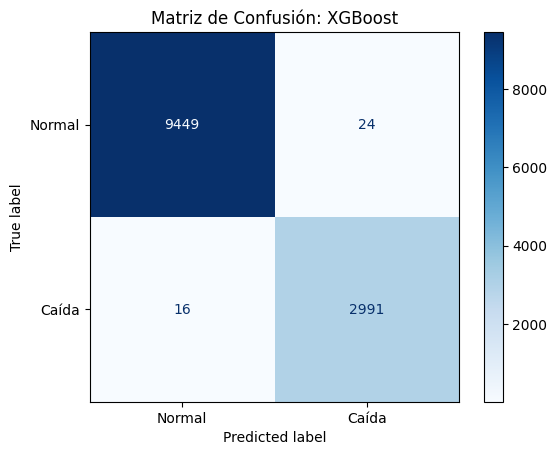

In [ ]:
# Matriz de confusión XGboost

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Dibujar matriz de confusión correctamente
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=['Normal', 'Caída'],
    cmap=plt.cm.Blues,
    values_format='d'
)

plt.title('Matriz de Confusión: XGBoost')
plt.show()

### (XGBoost) Curva de precisión - Recall

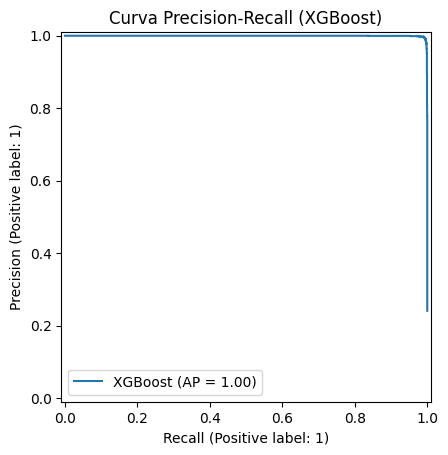

In [ ]:
# Curva de precisión - Recall

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Obtener probabilidades (clave para PR curve)
y_scores = xgb_model.predict_proba(X_test)[:, 1]

# Dibujar curva
disp = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_scores,
    name="XGBoost"
)

plt.title('Curva Precision-Recall (XGBoost)')
plt.show()

### (XGBoost) Probabilidades de caida(1)

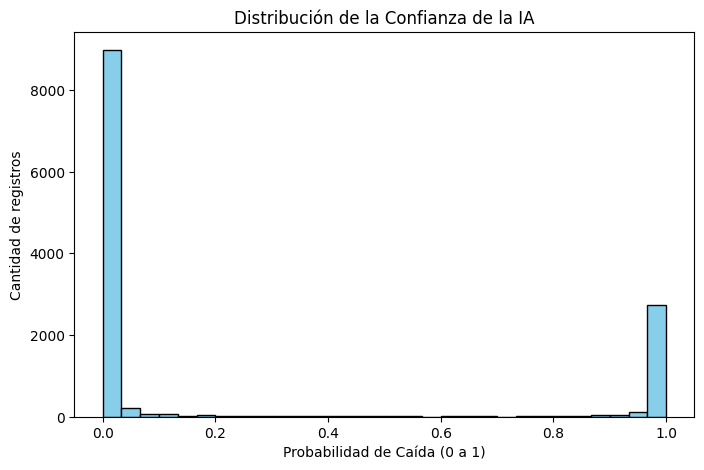

In [ ]:
# Obtenemos las probabilidades de la clase 'Caída' para XGboost

probs_caida =xgb_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_caida, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Confianza de la IA')
plt.xlabel('Probabilidad de Caída (0 a 1)')
plt.ylabel('Cantidad de registros')
plt.show()

### (XGBoost) Intensidad de caidas (SMV)

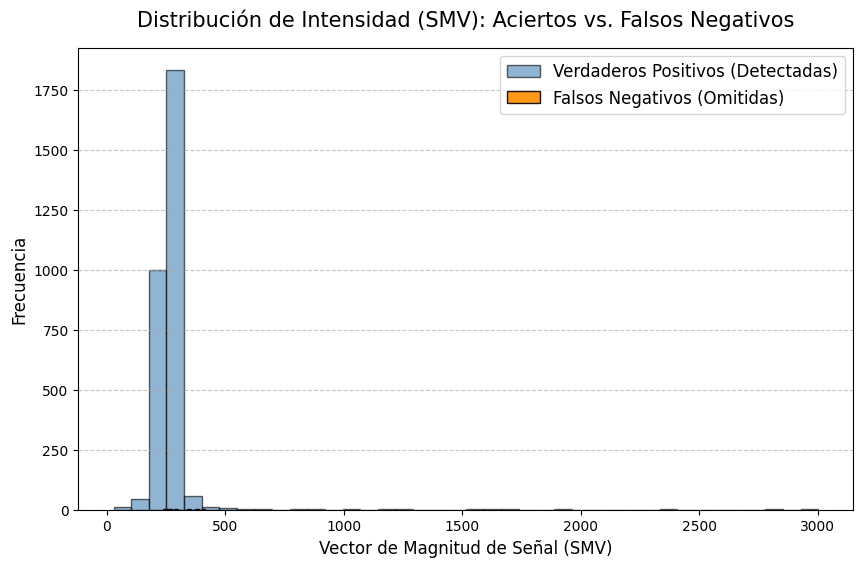

In [ ]:
# Histograma de Intensidad de Caídas (SMV) para XGBoost

import matplotlib.pyplot as plt
import numpy as np

# Filtramos SOLO los casos que en la realidad eran CAÍDAS (y_test == 1)
caidas_reales = X_test[y_test == 1]
predicciones_caidas_reales = xgb_model.predict(caidas_reales)

# Separamos el SMV de las que detectamos bien y de las que fallamos
smv_aciertos = caidas_reales[predicciones_caidas_reales == 1]['smv'] # Verdaderos Positivos
smv_fallos = caidas_reales[predicciones_caidas_reales == 0]['smv']   # Falsos Negativos

# Dibujamos el gráfico
plt.figure(figsize=(10, 6))

# Histograma de aciertos (Azul)
plt.hist(smv_aciertos, bins=40, alpha=0.6, label='Verdaderos Positivos (Detectadas)', color='steelblue', edgecolor='black')

# Histograma de fallos (Naranja)
plt.hist(smv_fallos, bins=20, alpha=0.9, label='Falsos Negativos (Omitidas)', color='darkorange', edgecolor='black')

# Personalización formal
plt.title('Distribución de Intensidad (SMV): Aciertos vs. Falsos Negativos', fontsize=15, pad=15)
plt.xlabel('Vector de Magnitud de Señal (SMV)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## (XGBoost) Optimitzación del modelo

### (XGBoost) Buscar mejores hiperparametros con GridSearch (se mantiene comentada para no cargar en tiempo de computación)

In [ ]:
# Buscar mejores hiperparámetros con GridSearch (XGBoost)
'''
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# Calcular peso de clases (equivalente a class_weight en RF)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Definimos el modelo base
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Definimos la rejilla de parámetros (adaptada a XGBoost)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Configuración del GridSearch
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',   # clave: optimizamos detección de caídas
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("=== EJECUTANDO GRID SEARCH XGBOOST ===")

# Entrenamiento
grid_search_xgb.fit(X_train, y_train)

# Mejor modelo
modelo_xgb_grid = grid_search_xgb.best_estimator_

print(f"\nMejores parámetros encontrados: {grid_search_xgb.best_params_}")

# Predicción
y_pred_xgb_grid = modelo_xgb_grid.predict(X_test)

# Evaluación
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb_grid))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb_grid))
'''

'\nfrom xgboost import XGBClassifier\nfrom sklearn.model_selection import GridSearchCV\nfrom sklearn.metrics import confusion_matrix, classification_report\n\n# Calcular peso de clases (equivalente a class_weight en RF)\nscale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])\n\n# Definimos el modelo base\nxgb_base = XGBClassifier(\n    random_state=42,\n    eval_metric=\'logloss\'\n)\n\n# Definimos la rejilla de parámetros (adaptada a XGBoost)\nparam_grid = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [4, 6, 8],\n    \'learning_rate\': [0.05, 0.1],\n    \'subsample\': [0.8, 1.0]\n}\n\n# Configuración del GridSearch\ngrid_search_xgb = GridSearchCV(\n    estimator=xgb_base,\n    param_grid=param_grid,\n    scoring=\'recall\',   # clave: optimizamos detección de caídas\n    cv=3,\n    n_jobs=-1,\n    verbose=1\n)\n\nprint("=== EJECUTANDO GRID SEARCH XGBOOST ===")\n\n# Entrenamiento\ngrid_search_xgb.fit(X_train, y_train)\n\n# Mejor modelo\nmodelo_xgb_grid = 

### (XGBoost) Entrenamiento modelo optimizado XGBOOST


Metricas modelo optimizado XGBoost
Accuracy (Exactitud global): 99.86%
Precision (Calidad alarmas): 99.77%
Recall (Caídas detectadas):  99.63%
F1-Score (Equilibrio):       99.70%
Average Precision (AP):      99.99%


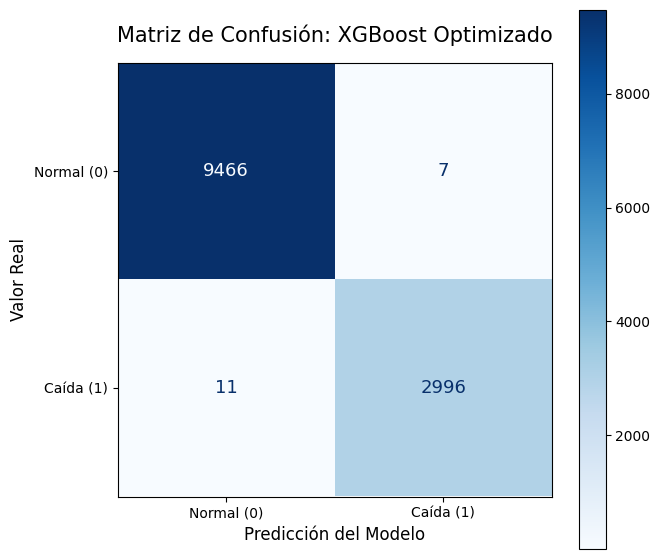

In [ ]:

import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

# Peso de clases (equivalente a class_weight)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Mejores hiperparámetros obtenidos con GridSearch
mejor_modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Entrenamiento
mejor_modelo_xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb_final = mejor_modelo_xgb.predict(X_test)
y_probs_xgb_final = mejor_modelo_xgb.predict_proba(X_test)[:, 1]

# metricas
print("\n" + "="*50)
print("Metricas modelo optimizado XGBoost")
print("="*50)

print(f"Accuracy (Exactitud global): {accuracy_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Precision (Calidad alarmas): {precision_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Recall (Caídas detectadas):  {recall_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"F1-Score (Equilibrio):       {f1_score(y_test, y_pred_xgb_final)*100:.2f}%")
print(f"Average Precision (AP):      {average_precision_score(y_test, y_probs_xgb_final)*100:.2f}%")

print("="*50)

# guardado local del modelo
nombre_archivo = 'modelo_sisfall_xgboost.pkl'
joblib.dump(mejor_modelo_xgb, nombre_archivo)


#Matriz de confusion
cm = confusion_matrix(y_test, y_pred_xgb_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal (0)', 'Caída (1)']
)

fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(
    cmap='Blues',
    ax=ax,
    values_format='d',
    text_kw={'fontsize': 13}
)

plt.title('Matriz de Confusión: XGBoost Optimizado', fontsize=15, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.show()


### (XGBoost) Pruebas cualitativas con modelo optimizado

In [ ]:
# Los mismos 4 casos que probamos en la prueba cualitativa con el modelo inicial, vamos a evaluarlos con el modelo optimizado

import pandas as pd

# Aseguramos el orden de las 10 columnas del modelo
columnas = X_train.columns.tolist()

# Datos registro los mismos registros de test que se han evaluado con el modelo inicial
# Formato: [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, smv, acc2_x, acc2_y, acc2_z]
datos_casos = [
    # CASO 1: ACIERTO CAÍDA
    [199.00, 50.00, -155.00, 51.00, 14.00, -4.00, 257.04, -378.00, 32.00, 976.00],
    # CASO 2: ACIERTO NORMAL
    [-17.00, -243.00, -114.00, 111.00, -573.00, -121.00, 269.17, 14.00, -1014.00, -432.00],
    # CASO 3: ANTES FALLO Falso Negativo
    [-15.00, -267.00, -118.00, 121.00, -587.00, -82.00, 292.30, 35.00, -1025.00, -428.00],
    # CASO 4: ANTES FALLO Falso Positivo
    [-26.00, -250.00, -31.00, -134.00, -195.00, 29.00, 253.25, 6.00, -1026.00, -110.00]
]

titulos = [
    "CASO 1: CAÍDA DETECTADA (Anterior Acierto)",
    "CASO 2: ACTIVIDAD NORMAL (Anterior Acierto)",
    "CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo)",
    "CASO 4: ALARMA FALSA (Anterior Falso Positivo)"
]

esperados = [1, 0, 1, 0]

print("=== EVALUACIÓN DEL MODELO OPTIMIZADO ===\n")

for i in range(len(datos_casos)):
    # Creamos el DataFrame con la estructura que el modelo conoce
    X_input = pd.DataFrame([datos_casos[i]], columns=columnas)

    # Predicción con el mejor modelo del GridSearch
    pred = mejor_modelo_xgb.predict(X_input)[0]
    prob = mejor_modelo_xgb.predict_proba(X_input)[0][pred] * 100

    print(f"--- {titulos[i]} ---")
    print(f"Output Esperado: {esperados[i]} | Output Real: {pred} ({prob:.2f}% confianza)")

    # Verificamos si la optimización ha corregido el error
    if pred == esperados[i]:
        status = "CORRECTO"
        if i >= 2: status += " (¡ERROR CORREGIDO!)"
    else:
        status = "INCORRECTO"

    print(f"Resultado: {status}\n")

=== EVALUACIÓN DEL MODELO OPTIMIZADO ===

--- CASO 1: CAÍDA DETECTADA (Anterior Acierto) ---
Output Esperado: 1 | Output Real: 1 (99.95% confianza)
Resultado: CORRECTO

--- CASO 2: ACTIVIDAD NORMAL (Anterior Acierto) ---
Output Esperado: 0 | Output Real: 1 (99.90% confianza)
Resultado: INCORRECTO

--- CASO 3: CAÍDA NO DETECTADA (Anterior Falso Negativo) ---
Output Esperado: 1 | Output Real: 1 (99.87% confianza)
Resultado: CORRECTO (¡ERROR CORREGIDO!)

--- CASO 4: ALARMA FALSA (Anterior Falso Positivo) ---
Output Esperado: 0 | Output Real: 1 (99.99% confianza)
Resultado: INCORRECTO



# (XGBoost) Guardado del artefacto en el bucket S3 o en la carpeta local  output/ del colab

In [ ]:
# Guardar el artefacto en el bucket S3 /output
'''
import joblib
import boto3

# Configuración de nombres y rutas
bucket_name = 'sisfall-fall-detection'
model_filename = 'modelo_sisfall_optimizado.pkl'
s3_path = f'output/{model_filename}'

# Guardar el modelo en la máquina temporal
# Empaquetamos directamente tu modelo XGBoost optimizado
joblib.dump(mejor_modelo_xgb, model_filename)
print(f"Modelo generado temporalmente: {model_filename}")

# Subida directa a Amazon S3
s3_client = boto3.client('s3')

try:
    print(f"Subiendo el artefacto a s3://{bucket_name}/{s3_path}...")
    s3_client.upload_file(model_filename, bucket_name, s3_path)
    print("¡Éxito! El artefacto XGBoost se ha guardado correctamente en tu bucket de S3.")

except Exception as e:
    print(f"Error al subir a S3: {e}")
'''

In [ ]:
# Guardar el artefacto (Model Artifact) localmente y en S3
import joblib
import boto3
import os
from botocore.exceptions import NoCredentialsError, ClientError

# Configuración de nombres y rutas
model_name = 'modelo_sisfall_optimizado.pkl'
bucket_name = 'sisfall-fall-detection'
local_output_dir = 'output/'
s3_path = f'output/{model_name}'

# Crear la carpeta output local si no existe (para Colab/GitHub)
if not os.path.exists(local_output_dir):
    os.makedirs(local_output_dir)
    print(f"Carpeta local '{local_output_dir}' creada.")

# Guardar el modelo localmente (mejor_modelo_xgb)
ruta_local_archivo = os.path.join(local_output_dir, model_name)
joblib.dump(mejor_modelo_xgb, ruta_local_archivo)
print(f"✔ Modelo guardado localmente en: {ruta_local_archivo}")

# Intento de subida a Amazon S3
try:
    print(f"Intentando subir el artefacto a s3://{bucket_name}/{s3_path}...")
    s3_client = boto3.client('s3')
    s3_client.upload_file(ruta_local_archivo, bucket_name, s3_path)
    print("¡Éxito! El artefacto ya está disponible en el bucket de S3.")

except (NoCredentialsError, ClientError, Exception) as e:
    print("\n No se pudo subir a S3 automáticamente.")
    print("El archivo se mantiene en la carpeta local '/output' de este entorno.")

✔ Modelo guardado localmente en: output/modelo_sisfall_optimizado.pkl
Intentando subir el artefacto a s3://sisfall-fall-detection/output/modelo_sisfall_optimizado.pkl...

 No se pudo subir a S3 automáticamente.
El archivo se mantiene en la carpeta local '/output' de este entorno.
